The goal of this experiment is to check the performance decay when using the drosophila parameter file for increasingly distant species. 

In [1]:
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
from Bio import Phylo
from io import StringIO

In [2]:
species = ! ls ../drosophila_data/

# Using one parameter file
results stored in `drosophila_phylo`

In [15]:
# link assembly in the result folder
for s in species:
    assembly = !  realpath ../drosophila_data/$s/*/*.fna
    assembly = assembly[0]
    target_folder = f'../results/drosophila_phylo/{s}'
    # ! mkdir $target_folder
    # ! ln -s $assembly $target_folder

In [17]:
# add drosophila parameter link to all species
for s in species:
    param = '/users/rg/fzanarello/software/geneid/param/Drosophila_melanogaster.7227.param'
    target_folder = f'../results/drosophila_phylo/{s}'
    # ! ln -s $param $target_folder

In [2]:
# prepare geneid command
with open('../job_commands/drosophila_preds.txt', 'w') as out:
    
    for sp in species:
        ref = ! realpath ../results/drosophila_phylo/$sp/*fna
        param = ! realpath ../results/drosophila_phylo/$sp/*param
        models = f'/users/rg/fzanarello/projects/geneid-bg/results/drosophila_phylo/{sp}/{sp}_dmelparam.gff3'
    
        command = f'time geneid -3P {param[0]} {ref[0]} > {models}'
        out.write(command + '\n')

# Building species specific parameter file 
results store in `raw`, `trained_params`,`drosophila_self`

In [3]:
# save list for training and prepare folders to save gff containing CDS from 1k genes and unzipped clean name assemblies  
! mkdir -p ../data/training_data/
! ls ../data/species/ | xargs -I {} mkdir -p ../data/training_data/{}

### clean assemblies

In [6]:
training_species = ! ls ../drosophila_data/

for sp in training_species:
    ref_assembly = ! realpath ../data/species/$sp/*/*.fna
    ref_assembly = ref_assembly[0]
    ref_assembly_name = ref_assembly.split('/')[-1]
    result_file = f'../data/training_data/{sp}/CLEAN_{ref_assembly_name}'

    # print (ref_assembly)
    # print (result_file)
    # print ()
    
    # ! bash ../scripts/clean_ref.sh $ref_assembly > $result_file

### extract CDS from annotations

In [9]:
training_species = ! ls ../drosophila_data/

for sp in training_species:
    ref_ann = ! realpath ../data/species/$sp/*/*.gff
    ref_ann = ref_ann[0]
    ref_ann_name = ref_ann.split('/')[-1]
    result_file = f'../data/training_data/{sp}/CDS_{ref_ann_name}'

    # print (ref_ann)
    # print (result_file)
    # print ()

    # ! bash ../scripts/get_CDS.sh $ref_ann > $result_file

### sample 1k genes from CDS annotations

In [11]:
training_species = ! ls ../drosophila_data/

for sp in training_species:
    CDS_ann = ! realpath ../data/training_data/$sp/CDS*.gff
    CDS_ann = CDS_ann[0]
    CDS_ann_name = CDS_ann.split('/')[-1]
    result_file = f'../data/training_data/{sp}/sample1k_{CDS_ann_name}'

    # print (CDS_ann)
    # print (result_file)
    # print ()

    # ! bash ../scripts/sample_CDS.sh $CDS_ann 1000 > $result_file

### prepare jobarray

In [6]:
training_species = ! ls ../drosophila_data/

with open('../job_commands/drosophila_training.txt', 'w') as out:

    for sp in training_species:
        
        sample1k_CDS = ! realpath ../data/training_data/$sp/sample1k*.gff
        sample1k_CDS = sample1k_CDS[0]
    
        clean_ref = ! realpath ../data/training_data/$sp/CLEAN*.fna
        clean_ref = clean_ref[0]
    
        result_folder = f'/no_backup/rg/fzanarello/projects/geneid-bg/results/raw/{sp}/'
        
        # print (sample1k_CDS)
        # print (clean_ref)
        # print (sp)
        # print (result_folder)
        # print ()
    
        geneidtrainer_command = f"singularity run \
                            /software/rg/images/geneidtrainerdocker.sif \
                            /scripts_geneid/geneidTRAINer4docker.pl \
                            -species {sp} \
                            -gff {sample1k_CDS} \
                            -fastas {clean_ref} \
                            -results {result_folder} \
                            -reduced no"
        out.write(geneidtrainer_command + '\n')

### Copy and prepare for pred

In [2]:
training_species = ! ls ../drosophila_data/

In [4]:
# link assembly 
for sp in training_species:
    target_folder = f'../results/drosophila_self/{sp}'
    ! mkdir -p $target_folder
    assembly = !  realpath ../drosophila_data/$sp/*/*.fna
    assembly = assembly[0]
    # ! ln -s $assembly $target_folder

In [14]:
# sort parameter files
for sp in training_species:
    param_file = !  realpath ../results/raw/$sp/*.optimized.param
    param_file = param_file[0]
    param_name = param_file.split('/')[-1]
    trained_target = f'../results/trained_params/{param_name}'

    # ! cp $param_file $trained_target

    trained_target_abs = ! realpath $trained_target
    trained_target_abs = trained_target_abs[0]
    pred_target = f'/users/rg/fzanarello/projects/geneid-bg/results/drosophila_self/{sp}/{param_name}'
    # ! ln -s $trained_target_abs $pred_target

In [15]:
# prepare geneid command
with open('../job_commands/drosophila_SELFpreds.txt', 'w') as out:
    
    for sp in training_species:
        ref = ! realpath ../results/drosophila_self/$sp/*fna
        param = ! realpath ../results/drosophila_self/$sp/*param
        models = f'/users/rg/fzanarello/projects/geneid-bg/results/drosophila_self/{sp}/{sp}_selfparam.gff3'
    
        command = f'time geneid -3P {param[0]} {ref[0]} > {models}'
        out.write(command + '\n')

# Prepare for compann
files are stred in `compann-nf_RUNS`

In [16]:
species = ! ls ../drosophila_data/

In [17]:
# link assembly, refseq and geneid anns in the result folder
for s in species:
    
    input_folder = f'../../compann-nf_RUNS/species/{s}/input'
    # ! mkdir -p $input_folder
    output_folder = f'../../compann-nf_RUNS/species/{s}/output'
    # ! mkdir -p $output_folder

    assembly = !  realpath ../drosophila_data/$s/*/*.fna
    assembly = assembly[0]
    # ! ln -s $assembly $input_folder

    refseq = !  realpath ../drosophila_data/$s/*/*.gff
    refseq = refseq[0]
    refseq_name = f'{input_folder}/RefSeq_{s.replace('.','_')}.gff'
    # ! ln -s $refseq $refseq_name

    geneid_dmel = !  realpath ../results/../results/drosophila_phylo/$s/*.gff3
    geneid_dmel = geneid_dmel[0]
    geneid_dmel_name = f'{input_folder}/geneidDMEL_{s.replace('.','_')}.gff3'
    # ! ln -s $geneid_dmel $geneid_dmel_name

    geneid_self = !  realpath ../results/drosophila_self/$s/*.gff3
    geneid_self = geneid_self[0]
    geneid_self_name = f'{input_folder}/geneidSELF_{s.replace('.','_')}.gff3'
    # ! ln -s $geneid_self $geneid_self_name
    

In [11]:
with open('../job_commands/drosophila_compann.sh', 'w') as out:
    
    for s in species:
        ref = ! realpath ../../compann-nf_RUNS/species/$s/input/*.fna
        ref = ref[0]
        
        input_folder = ! realpath ../../compann-nf_RUNS/species/$s/input
        input_folder = input_folder[0]
        
        output_folder = ! realpath ../../compann-nf_RUNS/species/$s/output
        output_folder = output_folder[0]
        
        cd_command = f'cd /users/rg/fzanarello/projects/compann-nf_RUNS/species/{s}'
        nfx_command = f"nextflow run -resume /users/rg/fzanarello/pipelines/compann-nf/main.nf -profile slurm  --gff_folder {input_folder} --outputFolder {output_folder} --ref {ref} --lineage diptera_odb10"
        out.write(cd_command + ' && ' + nfx_command + '\n')

# Plot results

In [3]:
species = ! ls ../drosophila_data/

In [4]:
for s in species:
    print (s.split('.')[1])

7217
7220
30025
7222
7227
7229
7234
7237
7240
7244
7260
7370


<Figure size 1000x500 with 0 Axes>

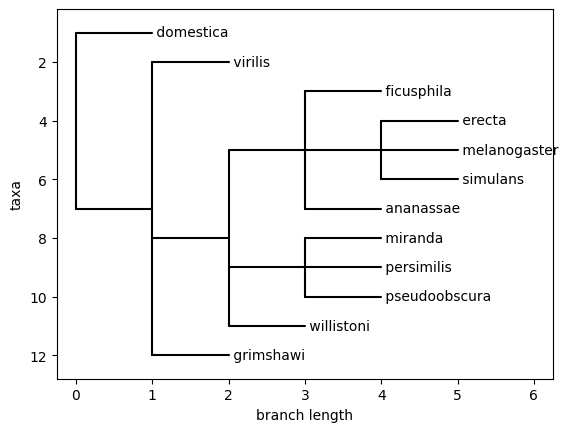

In [5]:
# Define the tree in Newick format
newick = "(Musca domestica,(Drosophila virilis,((Drosophila ficusphila,(Drosophila erecta,Drosophila melanogaster,Drosophila simulans),Drosophila ananassae),(Drosophila miranda,Drosophila persimilis,Drosophila pseudoobscura),Drosophila willistoni),Drosophila grimshawi));"

# Parse the tree
tree = Phylo.read(StringIO(newick), "newick")

# Plot the tree
fig = plt.figure(figsize=(10, 5))
Phylo.draw(tree)
plt.show()

In [6]:
for s in species:
    print (s.split('.')[0])

Drosophila_ananassae
Drosophila_erecta
Drosophila_ficusphila
Drosophila_grimshawi
Drosophila_melanogaster
Drosophila_miranda
Drosophila_persimilis
Drosophila_pseudoobscura
Drosophila_simulans
Drosophila_virilis
Drosophila_willistoni
Musca_domestica


In [7]:
species_order = [
    'Drosophila_melanogaster',
    'Drosophila_erecta',
    'Drosophila_simulans',
    'Drosophila_ananassae',
    'Drosophila_ficusphila',
    'Drosophila_miranda',
    'Drosophila_persimilis',
    'Drosophila_pseudoobscura',
    'Drosophila_willistoni',
    'Drosophila_grimshawi',
    'Drosophila_virilis',
    'Musca_domestica'
]

### Busco

In [8]:
busco_df = pd.DataFrame()
for s in species:
    tmp_df = pd.read_csv(f'../../compann-nf_RUNS/species/{s}/output/BUSCO/summary/combined_BUSCO_results.csv')
    tmp_df.set_index('metric', inplace=True)
    busco_df = pd.concat([busco_df, tmp_df], axis=1)

In [9]:
def get_species(x):
    x = x.split('_')
    species = '_'.join(x[2:-2])
    return species

In [10]:
busco_df = busco_df.transpose()
busco_df['Models'] = busco_df.index.map(lambda x : x.split('_')[1])
busco_df['Genus'] = busco_df.index.map(lambda x : x.split('_')[2])
busco_df['taxonID'] = busco_df.index.map(lambda x : x.split('_')[-2])
busco_df['Species'] = busco_df.index.map(get_species)
busco_df['Complete percentage'] = pd.to_numeric(busco_df['Complete percentage'])

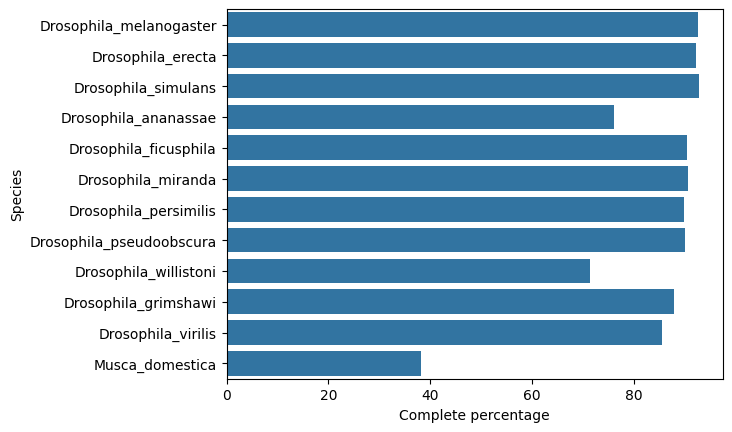

In [11]:
sns.barplot(data = busco_df[busco_df.Models == 'geneidDMEL'],
            y = 'Species',
            x = 'Complete percentage',
            order = species_order)
plt.show()

### Accuracy

In [12]:
metrics = ['base_level_Se', 'base_level_Pr',
           'exon_level_Se', 'exon_level_Pr',
           'locus_level_Se', 'locus_level_Pr']

In [13]:
acc_df = pd.DataFrame()

for s in species:
    gffcomapre_df = pd.read_csv(f'../../compann-nf_RUNS/species/{s}/output/gffcompare/summary/combined_gffcompare_extend.tsv')
    original_column = gffcomapre_df.columns.drop('comparison')
    gffcomapre_df['val'] = gffcomapre_df[original_column].bfill(axis=1).iloc[:, 0]
    gffcomapre_df = gffcomapre_df.drop(original_column, axis=1)
    
    gffcomapre_df['metric'] = gffcomapre_df.comparison.map(lambda x : x.split('-')[-1])
    gffcomapre_df['measure'] = gffcomapre_df['metric'].map(lambda x : x.split('_')[-1])
    gffcomapre_df['level'] = gffcomapre_df['metric'].map(lambda x : x.split('_')[0])
    
    gffcomapre_df['reference'] = gffcomapre_df.comparison.map(lambda x : x.split('_')[0])
    gffcomapre_df['query'] = gffcomapre_df.comparison.map(lambda x : x.split('_vs_')[1].split('_')[0])
    gffcomapre_df['Species'] = gffcomapre_df.comparison.map(lambda x : '_'.join(x.split('_vs_')[0].split('_')[1:-1]))
    gffcomapre_df['Genus'] = gffcomapre_df.Species.map(lambda x : x.split('_')[0])
    
    gffcomapre_df = gffcomapre_df[(gffcomapre_df['reference'] == 'RefSeq') & (gffcomapre_df['query'] == 'geneidDMEL')]
    gffcomapre_df = gffcomapre_df[gffcomapre_df.metric.isin(metrics)]
    gffcomapre_df.val = pd.to_numeric(gffcomapre_df.val)
    
    acc_df = pd.concat([acc_df, gffcomapre_df], axis=0)

acc_df = acc_df.reset_index()

In [14]:
acc_df

,index,comparison,val,metric,measure,level,reference,query,Species,Genus
0,2,RefSeq_Drosophila_ananassae_7217_vs_geneidDMEL...,70.4,base_level_Se,Se,base,RefSeq,geneidDMEL,Drosophila_ananassae,Drosophila
1,3,RefSeq_Drosophila_ananassae_7217_vs_geneidDMEL...,71.2,base_level_Pr,Pr,base,RefSeq,geneidDMEL,Drosophila_ananassae,Drosophila
2,4,RefSeq_Drosophila_ananassae_7217_vs_geneidDMEL...,56.1,exon_level_Se,Se,exon,RefSeq,geneidDMEL,Drosophila_ananassae,Drosophila
3,5,RefSeq_Drosophila_ananassae_7217_vs_geneidDMEL...,53.3,exon_level_Pr,Pr,exon,RefSeq,geneidDMEL,Drosophila_ananassae,Drosophila
4,8,RefSeq_Drosophila_ananassae_7217_vs_geneidDMEL...,33.4,locus_level_Se,Se,locus,RefSeq,geneidDMEL,Drosophila_ananassae,Drosophila
...,...,...,...,...,...,...,...,...,...,...
67,20,RefSeq_Musca_domestica_7370_vs_geneidDMEL_Musc...,68.6,base_level_Pr,Pr,base,RefSeq,geneidDMEL,Musca_domestica,Musca
68,21,RefSeq_Musca_domestica_7370_vs_geneidDMEL_Musc...,32.9,exon_level_Se,Se,exon,RefSeq,geneidDMEL,Musca_domestica,Musca
69,22,RefSeq_Musca_domestica_7370_vs_geneidDMEL_Musc...,33.9,exon_level_Pr,Pr,exon,RefSeq,geneidDMEL,Musca_domestica,Musca
70,25,RefSeq_Musca_domestica_7370_vs_geneidDMEL_Musc...,10.9,locus_level_Se,Se,locus,RefSeq,geneidDMEL,Musca_domestica,Musca


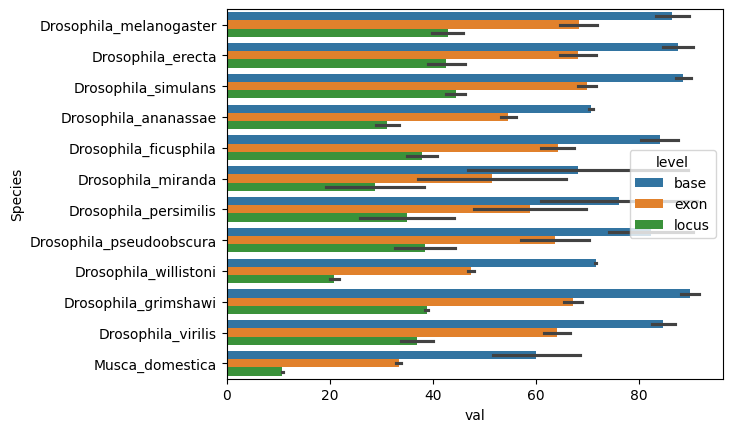

In [15]:
sns.barplot(data = acc_df ,
            y = 'Species',
            x = 'val',
            hue = 'level',
            order = species_order)
plt.show()

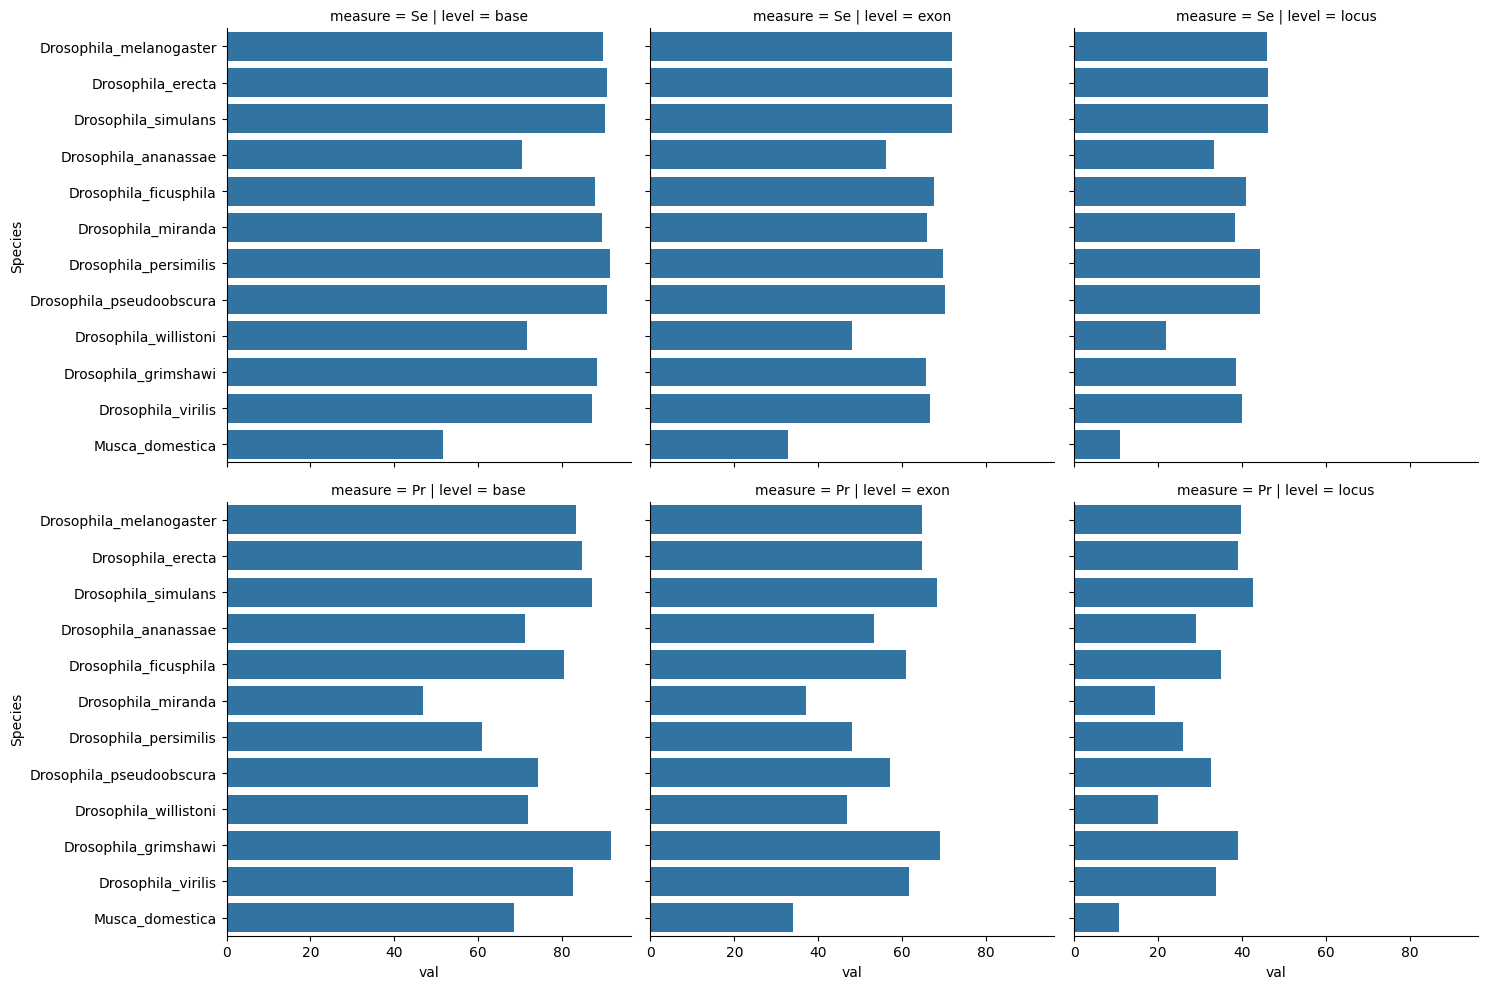

In [16]:
sns.catplot(data = acc_df ,
            y = 'Species',
            x = 'val',
            col = 'level',
            kind='bar',
            row = 'measure',
            order = species_order)
plt.show()

### GC content

In [17]:
species

['Drosophila_ananassae.7217',
 'Drosophila_erecta.7220',
 'Drosophila_ficusphila.30025',
 'Drosophila_grimshawi.7222',
 'Drosophila_melanogaster.7227',
 'Drosophila_miranda.7229',
 'Drosophila_persimilis.7234',
 'Drosophila_pseudoobscura.7237',
 'Drosophila_simulans.7240',
 'Drosophila_virilis.7244',
 'Drosophila_willistoni.7260',
 'Musca_domestica.7370']

In [18]:
gc_all = ! cat /no_backup/rg/references/stats/assemblies_GC.tsv
gc_dict = {x.split('/')[2].split('.')[0]:float(x.split('\t')[-1]) for x in gc_all if x.split('/')[2] in species}

In [19]:
gc_dict

{'Drosophila_simulans': 42.5,
 'Musca_domestica': 35.0,
 'Drosophila_ananassae': 42.0,
 'Drosophila_virilis': 40.5,
 'Drosophila_miranda': 45.0,
 'Drosophila_persimilis': 45.0,
 'Drosophila_willistoni': 37.5,
 'Drosophila_grimshawi': 36.5,
 'Drosophila_ficusphila': 41.0,
 'Drosophila_melanogaster': 42.0,
 'Drosophila_erecta': 42.5,
 'Drosophila_pseudoobscura': 45.0}

In [20]:
busco_df['GC'] = busco_df.Species.map(gc_dict)

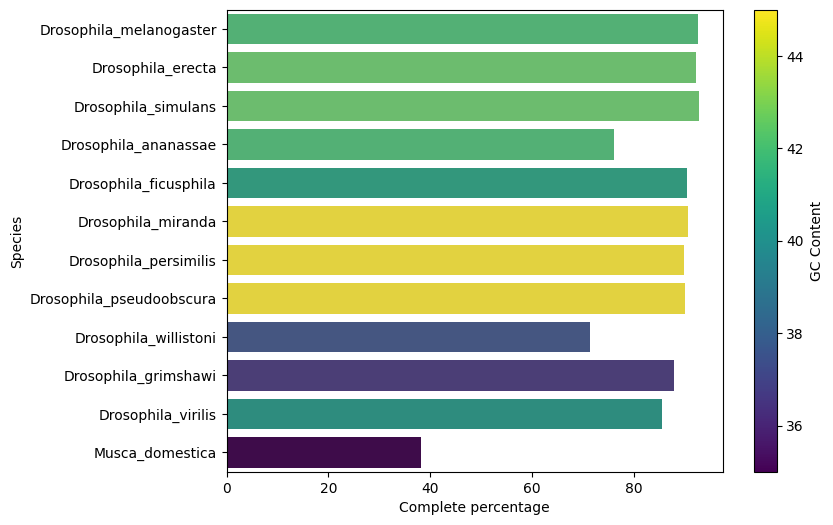

In [21]:
# Normalize the GC values to [0, 1]
norm = plt.Normalize(busco_df['GC'].min(), busco_df['GC'].max())

# Reorder the data and generate colors as a list
ordered_df = busco_df[busco_df.Models == 'geneidDMEL'].set_index('Species').loc[species_order]
colors = list(plt.cm.viridis(norm(ordered_df['GC'])))

# Create the figure and axis
fig, ax = plt.subplots(figsize=(8, 6))

# Use 'hue' to pass the color information and avoid the warning
sns.barplot(
    data=busco_df[busco_df.Models == 'geneidDMEL'],
    y='Species',
    x='Complete percentage',
    order=species_order,
    hue='Species',  # Assign the y-axis variable to hue
    dodge=False,    # Prevent splitting bars (needed when hue is used)
    palette=dict(zip(species_order, colors)),  # Map species to colors
    legend=False    # Disable the legend since it's not needed
)

# Add the colorbar
sm = plt.cm.ScalarMappable(cmap="viridis", norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, label='GC Content')

plt.show()

# compare with others

In [46]:
species_order = [
    'Drosophila_melanogaster',
    'Drosophila_erecta',
    'Drosophila_simulans',
    'Drosophila_ananassae',
    'Drosophila_ficusphila',
    'Drosophila_miranda',
    'Drosophila_persimilis',
    'Drosophila_pseudoobscura',
    'Drosophila_willistoni',
    'Drosophila_grimshawi',
    'Drosophila_virilis',
    'Musca_domestica'
]

### Busco

In [4]:
busco_df = pd.DataFrame()
for s in species:
    tmp_df = pd.read_csv(f'../../compann-nf_RUNS/species/{s}/output/BUSCO/summary/combined_BUSCO_results.csv')
    tmp_df.set_index('metric', inplace=True)
    busco_df = pd.concat([busco_df, tmp_df], axis=1)

In [5]:
def get_species(x):
    x = x.split('_')
    species = '_'.join(x[2:-2])
    return species

In [6]:
busco_df = busco_df.transpose()
busco_df['Models'] = busco_df.index.map(lambda x : x.split('_')[1])
busco_df['Genus'] = busco_df.index.map(lambda x : x.split('_')[2])
busco_df['taxonID'] = busco_df.index.map(lambda x : x.split('_')[-2])
busco_df['Species'] = busco_df.index.map(get_species)
busco_df['Complete percentage'] = pd.to_numeric(busco_df['Complete percentage'])

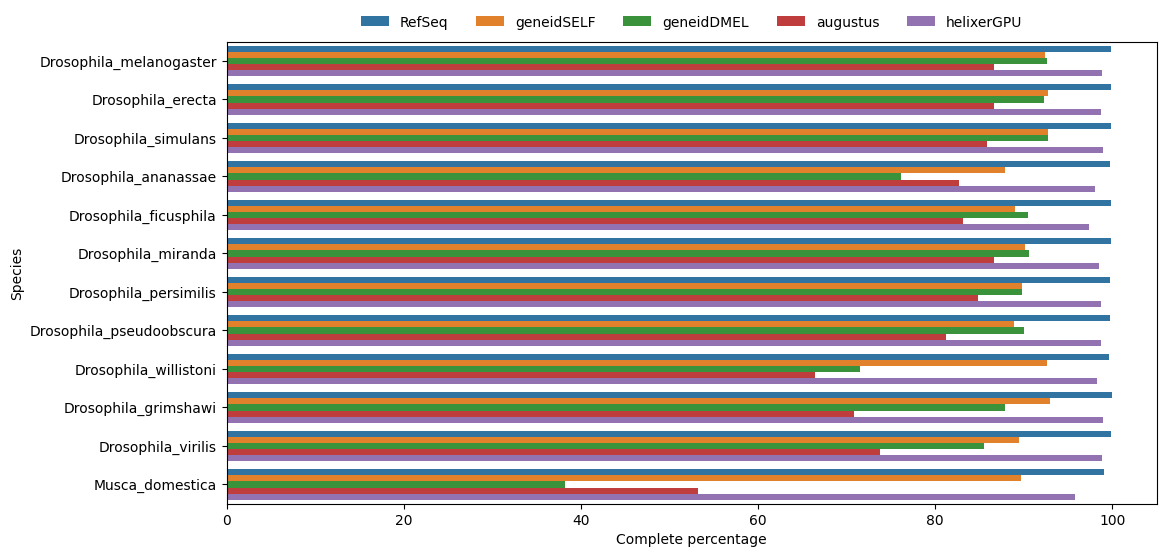

In [7]:
# Create the figure and axis
fig, ax = plt.subplots(figsize=(12, 6))

# Use 'hue' to pass the color information and avoid the warning
sns.barplot(
    data=busco_df,
    y='Species',
    x='Complete percentage',
    order=species_order,
    hue='Models',
    hue_order = ['RefSeq', 'geneidSELF','geneidDMEL', 'augustus', 'helixerGPU']
)

sns.move_legend(
    ax, "lower center",
    bbox_to_anchor=(.5, 1), ncol=5, title=None, frameon=False,
)

plt.show()

### accuracy

In [ ]:
metrics = ['base_level_Se', 'base_level_Pr',
           'exon_level_Se', 'exon_level_Pr',
           'locus_level_Se', 'locus_level_Pr']

acc_df = pd.DataFrame()

for s in species:
    gffcomapre_df = pd.read_csv(f'../../compann-nf_RUNS/species/{s}/output/gffcompare/summary/combined_gffcompare_extend.tsv')
    original_column = gffcomapre_df.columns.drop('comparison')
    gffcomapre_df['val'] = gffcomapre_df[original_column].bfill(axis=1).iloc[:, 0]
    gffcomapre_df = gffcomapre_df.drop(original_column, axis=1)
    
    gffcomapre_df['metric'] = gffcomapre_df.comparison.map(lambda x : x.split('-')[-1])
    gffcomapre_df['measure'] = gffcomapre_df['metric'].map(lambda x : x.split('_')[-1])
    gffcomapre_df['level'] = gffcomapre_df['metric'].map(lambda x : x.split('_')[0])
    
    gffcomapre_df['reference'] = gffcomapre_df.comparison.map(lambda x : x.split('_')[0])
    gffcomapre_df['query'] = gffcomapre_df.comparison.map(lambda x : x.split('_vs_')[1].split('_')[0])
    gffcomapre_df['Species'] = gffcomapre_df.comparison.map(lambda x : '_'.join(x.split('_vs_')[0].split('_')[1:-1]))
    gffcomapre_df['Genus'] = gffcomapre_df.Species.map(lambda x : x.split('_')[0])
    
    gffcomapre_df = gffcomapre_df[(gffcomapre_df['reference'] == 'RefSeq') & (gffcomapre_df['query'] != 'RefSeq')]
    gffcomapre_df = gffcomapre_df[gffcomapre_df.metric.isin(metrics)]
    gffcomapre_df.val = pd.to_numeric(gffcomapre_df.val)
    
    acc_df = pd.concat([acc_df, gffcomapre_df], axis=0)

acc_df = acc_df.reset_index()

In [9]:
acc_df

,index,comparison,val,metric,measure,level,reference,query,Species,Genus
0,189,RefSeq_Drosophila_ananassae_7217_vs_geneidSELF...,84.7,base_level_Se,Se,base,RefSeq,geneidSELF,Drosophila_ananassae,Drosophila
1,190,RefSeq_Drosophila_ananassae_7217_vs_geneidSELF...,77.8,base_level_Pr,Pr,base,RefSeq,geneidSELF,Drosophila_ananassae,Drosophila
2,191,RefSeq_Drosophila_ananassae_7217_vs_geneidSELF...,66.1,exon_level_Se,Se,exon,RefSeq,geneidSELF,Drosophila_ananassae,Drosophila
3,192,RefSeq_Drosophila_ananassae_7217_vs_geneidSELF...,60.7,exon_level_Pr,Pr,exon,RefSeq,geneidSELF,Drosophila_ananassae,Drosophila
4,195,RefSeq_Drosophila_ananassae_7217_vs_geneidSELF...,39.9,locus_level_Se,Se,locus,RefSeq,geneidSELF,Drosophila_ananassae,Drosophila
...,...,...,...,...,...,...,...,...,...,...
283,241,RefSeq_Musca_domestica_7370_vs_helixerGPU_Musc...,86.3,base_level_Pr,Pr,base,RefSeq,helixerGPU,Musca_domestica,Musca
284,242,RefSeq_Musca_domestica_7370_vs_helixerGPU_Musc...,84.1,exon_level_Se,Se,exon,RefSeq,helixerGPU,Musca_domestica,Musca
285,243,RefSeq_Musca_domestica_7370_vs_helixerGPU_Musc...,71.7,exon_level_Pr,Pr,exon,RefSeq,helixerGPU,Musca_domestica,Musca
286,246,RefSeq_Musca_domestica_7370_vs_helixerGPU_Musc...,55.3,locus_level_Se,Se,locus,RefSeq,helixerGPU,Musca_domestica,Musca


In [10]:
def calculate_f1(precision, recall):
    """Calculate the F1 score given precision and recall."""
    if precision + recall == 0:
        return 0
    return round(2 * (precision * recall) / (precision + recall),1)

def compute_f1_scores(df):
    """
    Compute F1 scores for base, exon and locus levels from a DataFrame, grouping by Species, Genus, and Query.

    Parameters:
    df (pd.DataFrame): DataFrame with columns ['metric', 'val', 'Species', 'Genus', 'query'].

    Returns:
    pd.DataFrame: A new DataFrame with F1 scores computed for each species-query combination.
    """
    
    # Pivot the data for easier access
    pivot_df = df.pivot(index=["Species", "Genus", "query"], columns="metric", values="val").reset_index()

    # Calculate F1 scores
    pivot_df["base_level_F1"] = pivot_df.apply(
        lambda row: calculate_f1(row.get("base_level_Pr", 0), row.get("base_level_Se", 0)), axis=1
    )
    pivot_df["exon_level_F1"] = pivot_df.apply(
        lambda row: calculate_f1(row.get("exon_level_Pr", 0), row.get("exon_level_Se", 0)), axis=1
    )
    pivot_df["locus_level_F1"] = pivot_df.apply(
        lambda row: calculate_f1(row.get("locus_level_Pr", 0), row.get("locus_level_Se", 0)), axis=1
    )

    result_df = pivot_df.melt(id_vars=['Species','Genus','query'],
           value_vars=['base_level_Pr','base_level_Se','exon_level_Pr',
                       'exon_level_Se','locus_level_Pr','locus_level_Se',
                       'base_level_F1','exon_level_F1','locus_level_F1'])
    
    result_df['measure'] = result_df['metric'].map(lambda x : x.split('_')[-1])
    result_df['level'] = result_df['metric'].map(lambda x : x.split('_')[0])
    
    return result_df

In [11]:
f1_df = compute_f1_scores(acc_df)

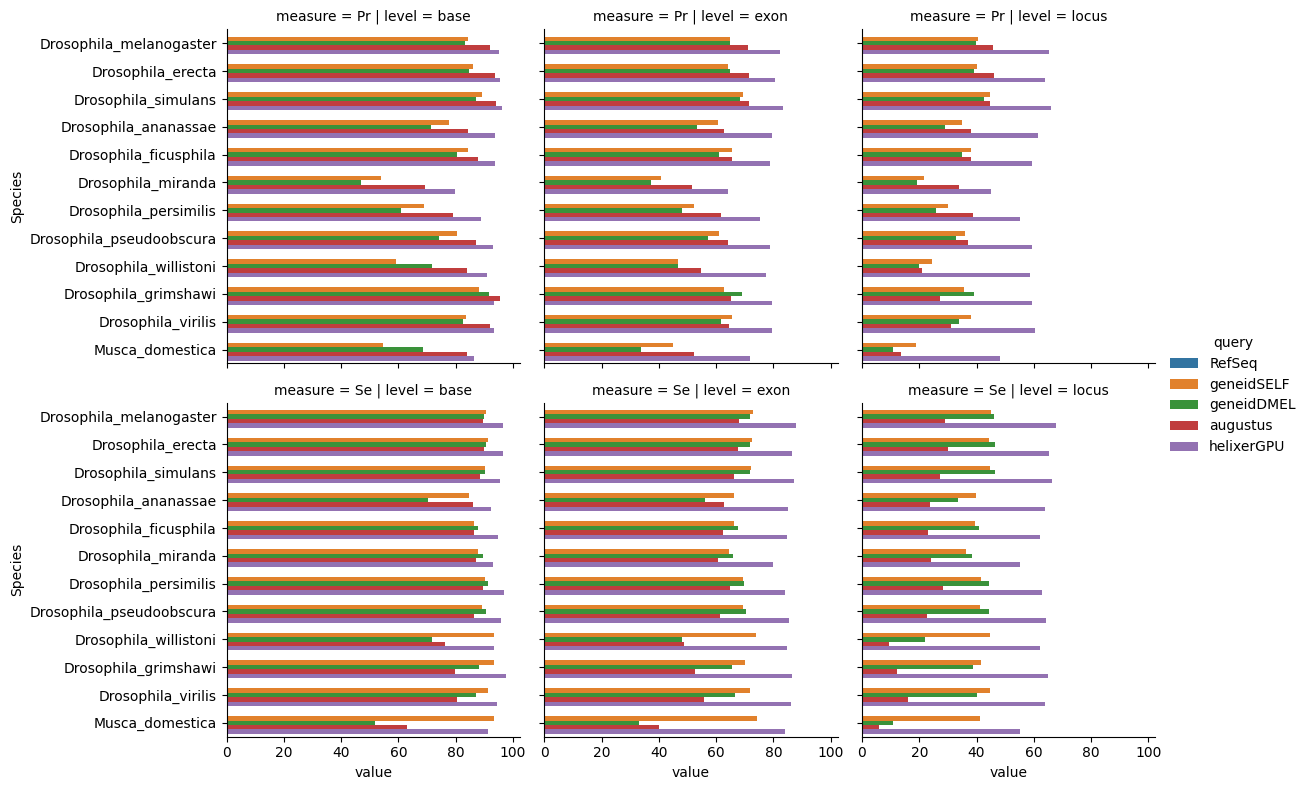

In [12]:
sns.catplot(data = f1_df[f1_df.measure.isin(['Pr','Se'])] ,
            y = 'Species',
            x = 'value',
            col = 'level',
            kind='bar',
            row = 'measure',
            order = species_order,
            hue='query',
            height=4, aspect=1,
            hue_order = ['RefSeq', 'geneidSELF','geneidDMEL', 'augustus', 'helixerGPU'])
plt.show()

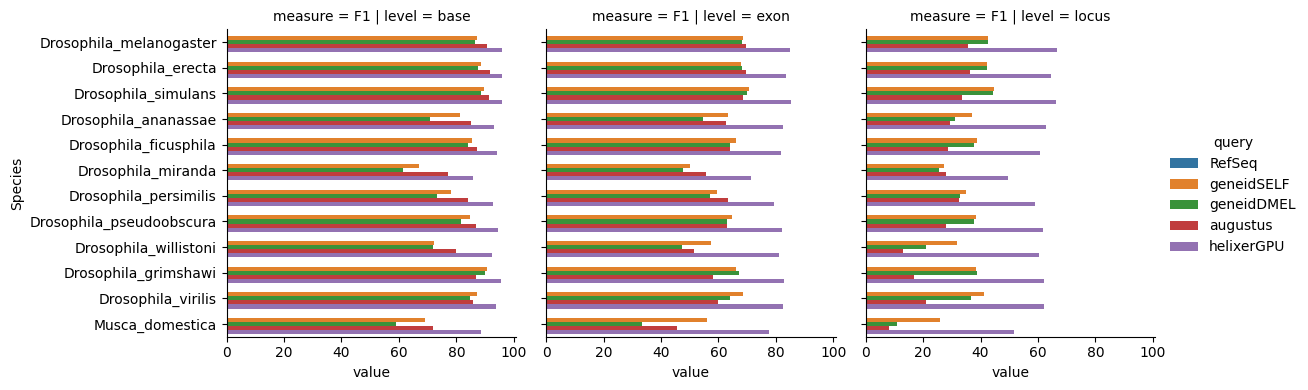

In [13]:
sns.catplot(data = f1_df[f1_df.measure == 'F1'] ,
            y = 'Species',
            x = 'value',
            col = 'level',
            kind='bar',
            row = 'measure',
            order = species_order,
            hue='query',
            height=4, aspect=1,
            hue_order = ['RefSeq', 'geneidSELF','geneidDMEL', 'augustus', 'helixerGPU'])
plt.show()

### summary

In [14]:
musca_res_files = ! find /users/rg/fzanarello/projects/compann-nf_RUNS/species/Musca_domestica.7370/output/summary_stat/ -name 'summary_stats_combined.csv'
dmel_res_files = ! find /users/rg/fzanarello/projects/compann-nf_RUNS/species/Drosophila_melanogaster.7227/output/summary_stat/ -name 'summary_stats_combined.csv'
dvir_res_files = ! find /users/rg/fzanarello/projects/compann-nf_RUNS/species/Drosophila_virilis.7244/output/summary_stat/ -name 'summary_stats_combined.csv'

In [ ]:
all_
for s in species:
    gffcomapre_df = pd.read_csv(f'../../compann-nf_RUNS/species/{s}/output/gffcompare/summary/combined_gffcompare_extend.tsv')

In [33]:
summary_res_files = dmel_res_files + dvir_res_files + musca_res_files

In [34]:
def get_species(x):
    species = '_'.join(x.split('_')[1:3])
    return species

In [35]:
def get_program(x):
    program = x.split('_')[0]
    return (program)

In [47]:
summary_df = pd.DataFrame()
for s in species:   
    tmp_df = pd.read_csv(f'../../compann-nf_RUNS/species/{s}/output/summary_stat/summary_stats_combined.csv')
    
    tmp_df['program'] = tmp_df['File Name'].map(get_program)
    tmp_df['Species'] = tmp_df['File Name'].map(get_species)
    
    summary_df = pd.concat([summary_df, tmp_df], axis=0)

summary_df = summary_df.drop_duplicates().reset_index()

In [41]:
summary_df = pd.DataFrame()
for f in summary_res_files:   
    tmp_df = pd.read_csv(f)
    
    tmp_df['program'] = tmp_df['File Name'].map(get_program)
    tmp_df['Species'] = tmp_df['File Name'].map(get_species)
    
    summary_df = pd.concat([summary_df, tmp_df], axis=0)

summary_df = summary_df.drop_duplicates().reset_index()

In [48]:
minimal_df = summary_df[summary_df['Type'].isin(['cds','gene'])]

In [49]:
minimal_df

,index,File Name,Full/200+,Type,Number,Size total (kb),Size mean (bp),program,Species
0,0,geneidDMEL_Drosophila_ananassae_7217,Full,cds,63476,24019.71,378.41,geneidDMEL,Drosophila_ananassae
2,2,geneidDMEL_Drosophila_ananassae_7217,Full,gene,18910,95892.85,5071.01,geneidDMEL,Drosophila_ananassae
6,6,RefSeq_Drosophila_ananassae_7217,Full,cds,155462,60971.08,392.19,RefSeq,Drosophila_ananassae
8,8,RefSeq_Drosophila_ananassae_7217,Full,gene,16789,111999.23,6670.99,RefSeq,Drosophila_ananassae
20,20,geneidSELF_Drosophila_ananassae_7217,Full,cds,64816,26264.69,405.22,geneidSELF,Drosophila_ananassae
...,...,...,...,...,...,...,...,...,...
728,51,geneidDMEL_Musca_domestica_7370_longisoforms_2...,200+,gene,17670,382189.68,21629.30,geneidDMEL,Musca_domestica
731,54,geneidSELF_Musca_domestica_7370_longisoforms_2...,200+,cds,124490,50614.27,406.57,geneidSELF,Musca_domestica
732,55,geneidSELF_Musca_domestica_7370_longisoforms_2...,200+,gene,37991,390232.11,10271.70,geneidSELF,Musca_domestica
735,58,helixerGPU_Musca_domestica_7370_longisoforms_2...,200+,cds,88419,31308.92,354.10,helixerGPU,Musca_domestica


In [56]:
melt_df = minimal_df.melt(id_vars= ['File Name','Full/200+','Type','program','Species'],
                          value_vars= ['Number','Size total (kb)','Size mean (bp)'])

In [57]:
melt_df

,File Name,Full/200+,Type,program,Species,variable,value
0,geneidDMEL_Drosophila_ananassae_7217,Full,cds,geneidDMEL,Drosophila_ananassae,Number,63476.00
1,geneidDMEL_Drosophila_ananassae_7217,Full,gene,geneidDMEL,Drosophila_ananassae,Number,18910.00
2,RefSeq_Drosophila_ananassae_7217,Full,cds,RefSeq,Drosophila_ananassae,Number,155462.00
3,RefSeq_Drosophila_ananassae_7217,Full,gene,RefSeq,Drosophila_ananassae,Number,16789.00
4,geneidSELF_Drosophila_ananassae_7217,Full,cds,geneidSELF,Drosophila_ananassae,Number,64816.00
...,...,...,...,...,...,...,...
715,geneidDMEL_Musca_domestica_7370_longisoforms_2...,200+,gene,geneidDMEL,Musca_domestica,Size mean (bp),21629.30
716,geneidSELF_Musca_domestica_7370_longisoforms_2...,200+,cds,geneidSELF,Musca_domestica,Size mean (bp),406.57
717,geneidSELF_Musca_domestica_7370_longisoforms_2...,200+,gene,geneidSELF,Musca_domestica,Size mean (bp),10271.70
718,helixerGPU_Musca_domestica_7370_longisoforms_2...,200+,cds,helixerGPU,Musca_domestica,Size mean (bp),354.10


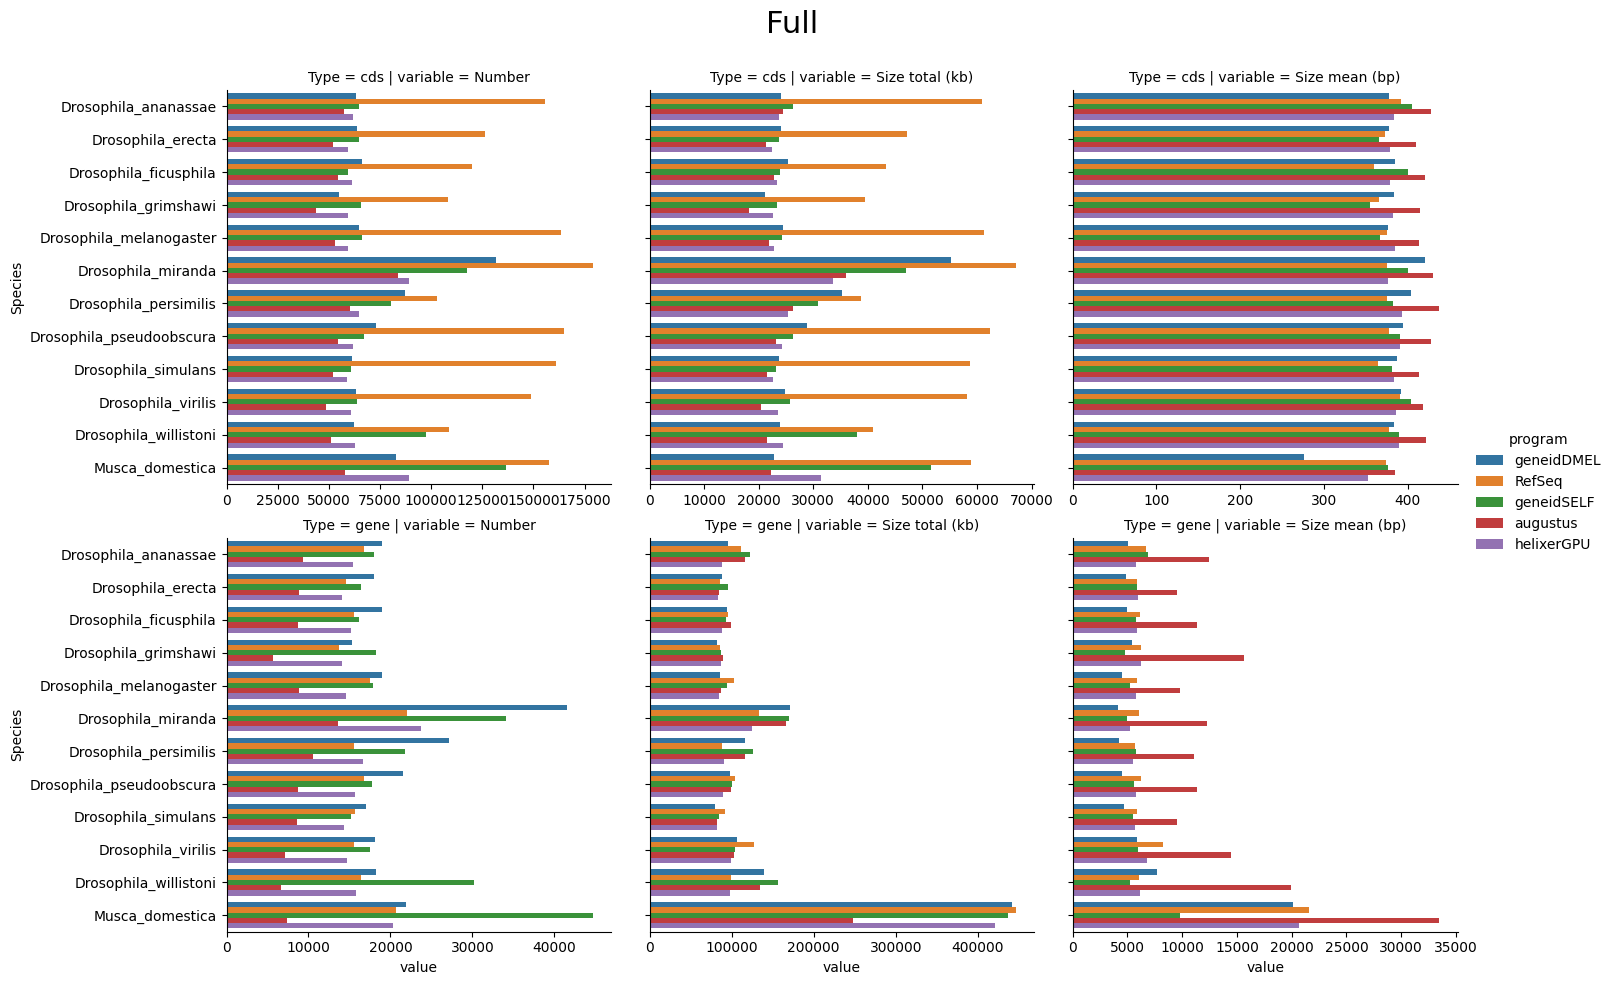

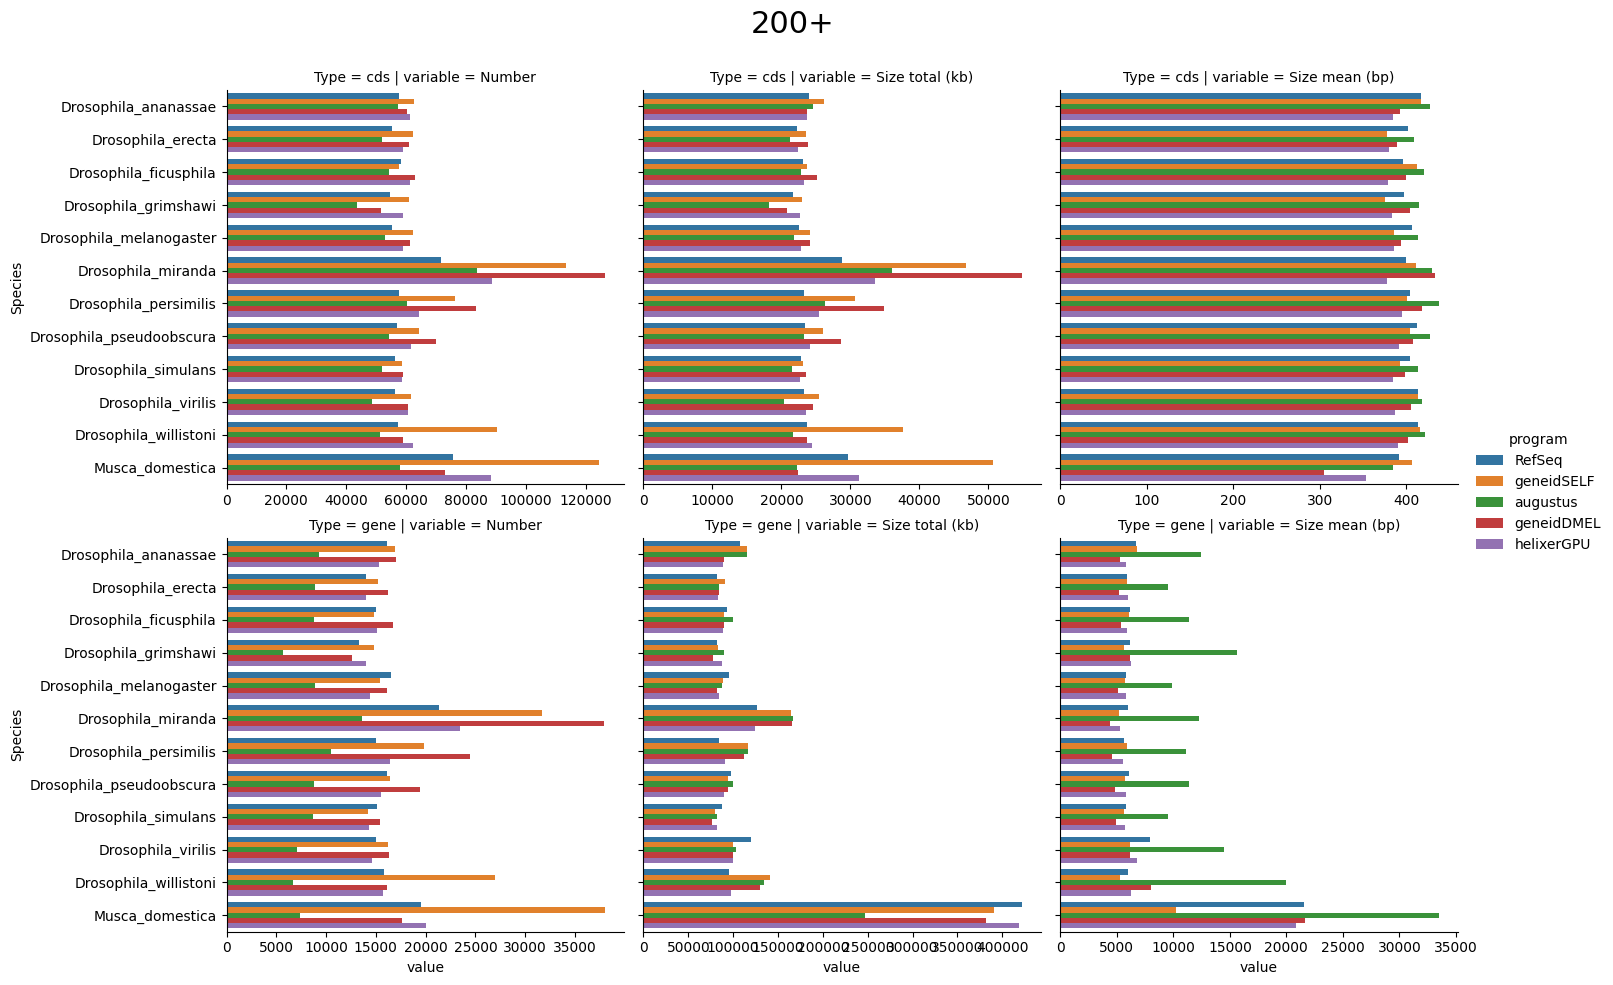

In [68]:
for mode in ['Full','200+']:
    a = sns.catplot(data = melt_df[melt_df['Full/200+'] == mode],
                    y = 'Species',
                    x = 'value',
                    hue = 'program', 
                    kind = 'bar', 
                    col = 'variable',
                    row = 'Type',
                    sharex = False
                   )
    a.fig.subplots_adjust(top=0.9)
    a.fig.suptitle(mode, size = 22)